In [6]:
import pandas as pd
import numpy as np

In [7]:
data=pd.read_csv('diamond.csv')
data

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [8]:
d1=pd.DataFrame({'ID':[1,2,3,5],
                'class':[9,10,11,12]})
d1

,ID,class
0,1,9
1,2,10
2,3,11
3,5,12


In [9]:
d2=pd.DataFrame({'ID':[1,2,3,4],
                 'Name':['A','B','C','D']})
d2

,ID,Name
0,1,A
1,2,B
2,3,C
3,4,D


In [10]:
pd.merge(d1,d2, on ='ID')

,ID,class,Name
0,1,9,A
1,2,10,B
2,3,11,C


In [11]:
n1=pd.merge(d1,d2, how='inner',on='ID')
n1

,ID,class,Name
0,1,9,A
1,2,10,B
2,3,11,C


In [12]:
n2=pd.merge(d1,d2, how='left',on='ID')
n2

,ID,class,Name
0,1,9,A
1,2,10,B
2,3,11,C
3,5,12,NaN


In [13]:
n3=pd.merge(d1,d2, how='right',on='ID')
n3

,ID,class,Name
0,1,9.0,A
1,2,10.0,B
2,3,11.0,C
3,4,NaN,D


In [14]:
n4=pd.merge(d1,d2, how='outer',on='ID')
n4

,ID,class,Name
0,1,9.0,A
1,2,10.0,B
2,3,11.0,C
3,4,NaN,D
4,5,12.0,NaN


In [15]:
df_1=pd.DataFrame({'ID':[1,2,3,5],
                'class':[9,10,11,12]},index=[11,22,32,44])
df_1


,ID,class
11,1,9
22,2,10
32,3,11
44,5,12


In [16]:
df_2=pd.DataFrame({'ID':[1,2,3,4],
                 'Name':['A','B','C','D']},index=[11,22,33,44])
df_2

,ID,Name
11,1,A
22,2,B
33,3,C
44,4,D


In [17]:
pd.merge(df_1,df_2, how='inner',on='ID')


,ID,class,Name
0,1,9,A
1,2,10,B
2,3,11,C


In [18]:
pd.merge(df_1,df_2, left_index=True,right_index=True)

,ID_x,class,ID_y,Name
11,1,9,1,A
22,2,10,2,B
44,5,12,4,D


In [19]:

data={
    'Age':[25,np.nan,30,22,np.nan],
    'Score':[85,90,np.nan,75,80],
    'City':['New York',np.nan,'Paris','London','Paris'],
}
dataf=pd.DataFrame(data)
print("Original DataFrame:\n",dataf)

Original DataFrame:
     Age  Score      City
0  25.0   85.0  New York
1   NaN   90.0       NaN
2  30.0    NaN     Paris
3  22.0   75.0    London
4   NaN   80.0     Paris


# detecting missing values


In [20]:
dataf.isnull()

,Age,Score,City
0,False,False,False
1,True,False,True
2,False,True,False
3,False,False,False
4,True,False,False


In [21]:
dataf.isnull().sum()

Age      2
Score    1
City     1
dtype: int64

In [22]:
dataf.notnull()

,Age,Score,City
0,True,True,True
1,False,True,False
2,True,False,True
3,True,True,True
4,False,True,True


In [23]:
df_clean_rows=dataf.dropna()
df_clean_cols=dataf.dropna(axis=1)
df_clean_subset=dataf.dropna(subset=['Age'])



In [24]:

df_clean_rows


,Age,Score,City
0,25.0,85.0,New York
3,22.0,75.0,London


In [25]:
df_clean_cols

""
0
1
2
3
4


In [26]:
df_clean_subset

,Age,Score,City
0,25.0,85.0,New York
2,30.0,NaN,Paris
3,22.0,75.0,London


In [27]:
df_zero=dataf.fillna(0)
df_zero

,Age,Score,City
0,25.0,85.0,New York
1,0.0,90.0,0
2,30.0,0.0,Paris
3,22.0,75.0,London
4,0.0,80.0,Paris


In [28]:
dataf['Age']=dataf['Age'].fillna(dataf['Age'].mean())
dataf['Age']

0    25.000000
1    25.666667
2    30.000000
3    22.000000
4    25.666667
Name: Age, dtype: float64

In [29]:
dataf['City']=dataf['City'].fillna(dataf['City'].mode()[0])
dataf['City']

0    New York
1       Paris
2       Paris
3      London
4       Paris
Name: City, dtype: object

# Time-series interpolation

In [30]:
df_ffill=dataf.ffill
df_bfill=dataf.bfill

In [31]:
from sklearn.impute import SimpleImputer, KNNImputer 
mean_imputer = SimpleImputer(strategy='mean')
dataf[['Age','Score']]=mean_imputer.fit_transform(dataf[['Age','Score']])
dataf[['Age','Score']]

                                            

,Age,Score
0,25.000000,85.0
1,25.666667,90.0
2,30.000000,82.5
3,22.000000,75.0
4,25.666667,80.0


In [34]:
knn_imputer=KNNImputer(n_neighbors=2)
dataf_knn=knn_imputer.fit_transform(dataf[['Age','Score']])
dataf_knn


array([[25.        , 85.        ],
       [25.66666667, 90.        ],
       [30.        , 82.5       ],
       [22.        , 75.        ],
       [25.66666667, 80.        ]])

In [43]:
import pandas as pd

# 1. Create a sample DataFrame with duplicate rows
data = {
    'Name': ['Alice', 'Bob', 'Alice', 'Alice', 'Charlie'],
    'Age': [25, 40, 25, 26, 35],
    'City': ['New York', 'Paris', 'New York', 'London', 'Berlin']
}

dfr = pd.DataFrame(data)

print("Original DataFrame")
print(dfr)

print("\n" + "=" * 40 + "\n")

Original DataFrame
      Name  Age      City
0    Alice   25  New York
1      Bob   40     Paris
2    Alice   25  New York
3    Alice   26    London
4  Charlie   35    Berlin




In [44]:
dfr_no_duplicate=dfr.drop_duplicates()
print("1.After removing exact duplicate(keeps  first):")
print(dfr_no_duplicate)
print("\n" + "="*40 + "\n" )

1.After removing exact duplicate(keeps  first):
      Name  Age      City
0    Alice   25  New York
1      Bob   40     Paris
3    Alice   26    London
4  Charlie   35    Berlin




In [48]:
# 4. Remove duplicates nd keep the LAST occurence 
df_keep_last = dfr.drop_duplicates(subset = ['Name'],keep = 'last')
print("3. keep LAST occurence of duplicate nmaes: ")
print(df_keep_last)
print("\n" + "="*40 + "\n")

3. keep LAST occurence of duplicate nmaes: 
      Name  Age    City
1      Bob   40   Paris
3    Alice   26  London
4  Charlie   35  Berlin




In [49]:
# 5. Drop All occurrence of duplicates completely

dfr_drop_all = dfr.drop_duplicates(subset = ['Name'],keep = False)
print("4. Drop ALL rows that have duplicate names (keep = False): ")
print(dfr_drop_all)
print("\n" + "="*40 + "\n")

4. Drop ALL rows that have duplicate names (keep = False): 
      Name  Age    City
1      Bob   40   Paris
4  Charlie   35  Berlin




In [47]:
h_df=pd.read_csv('train.csv')
h_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [51]:
h_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [52]:
h_df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [53]:
h_df.isnull()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
3,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1456,False,False,False,False,False,False,True,False,False,False,...,False,True,False,True,False,False,False,False,False,False
1457,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1458,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False


In [54]:
h_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [55]:
pd.set_option('display.max_rows', None)

print(h_df.isnull().sum())

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

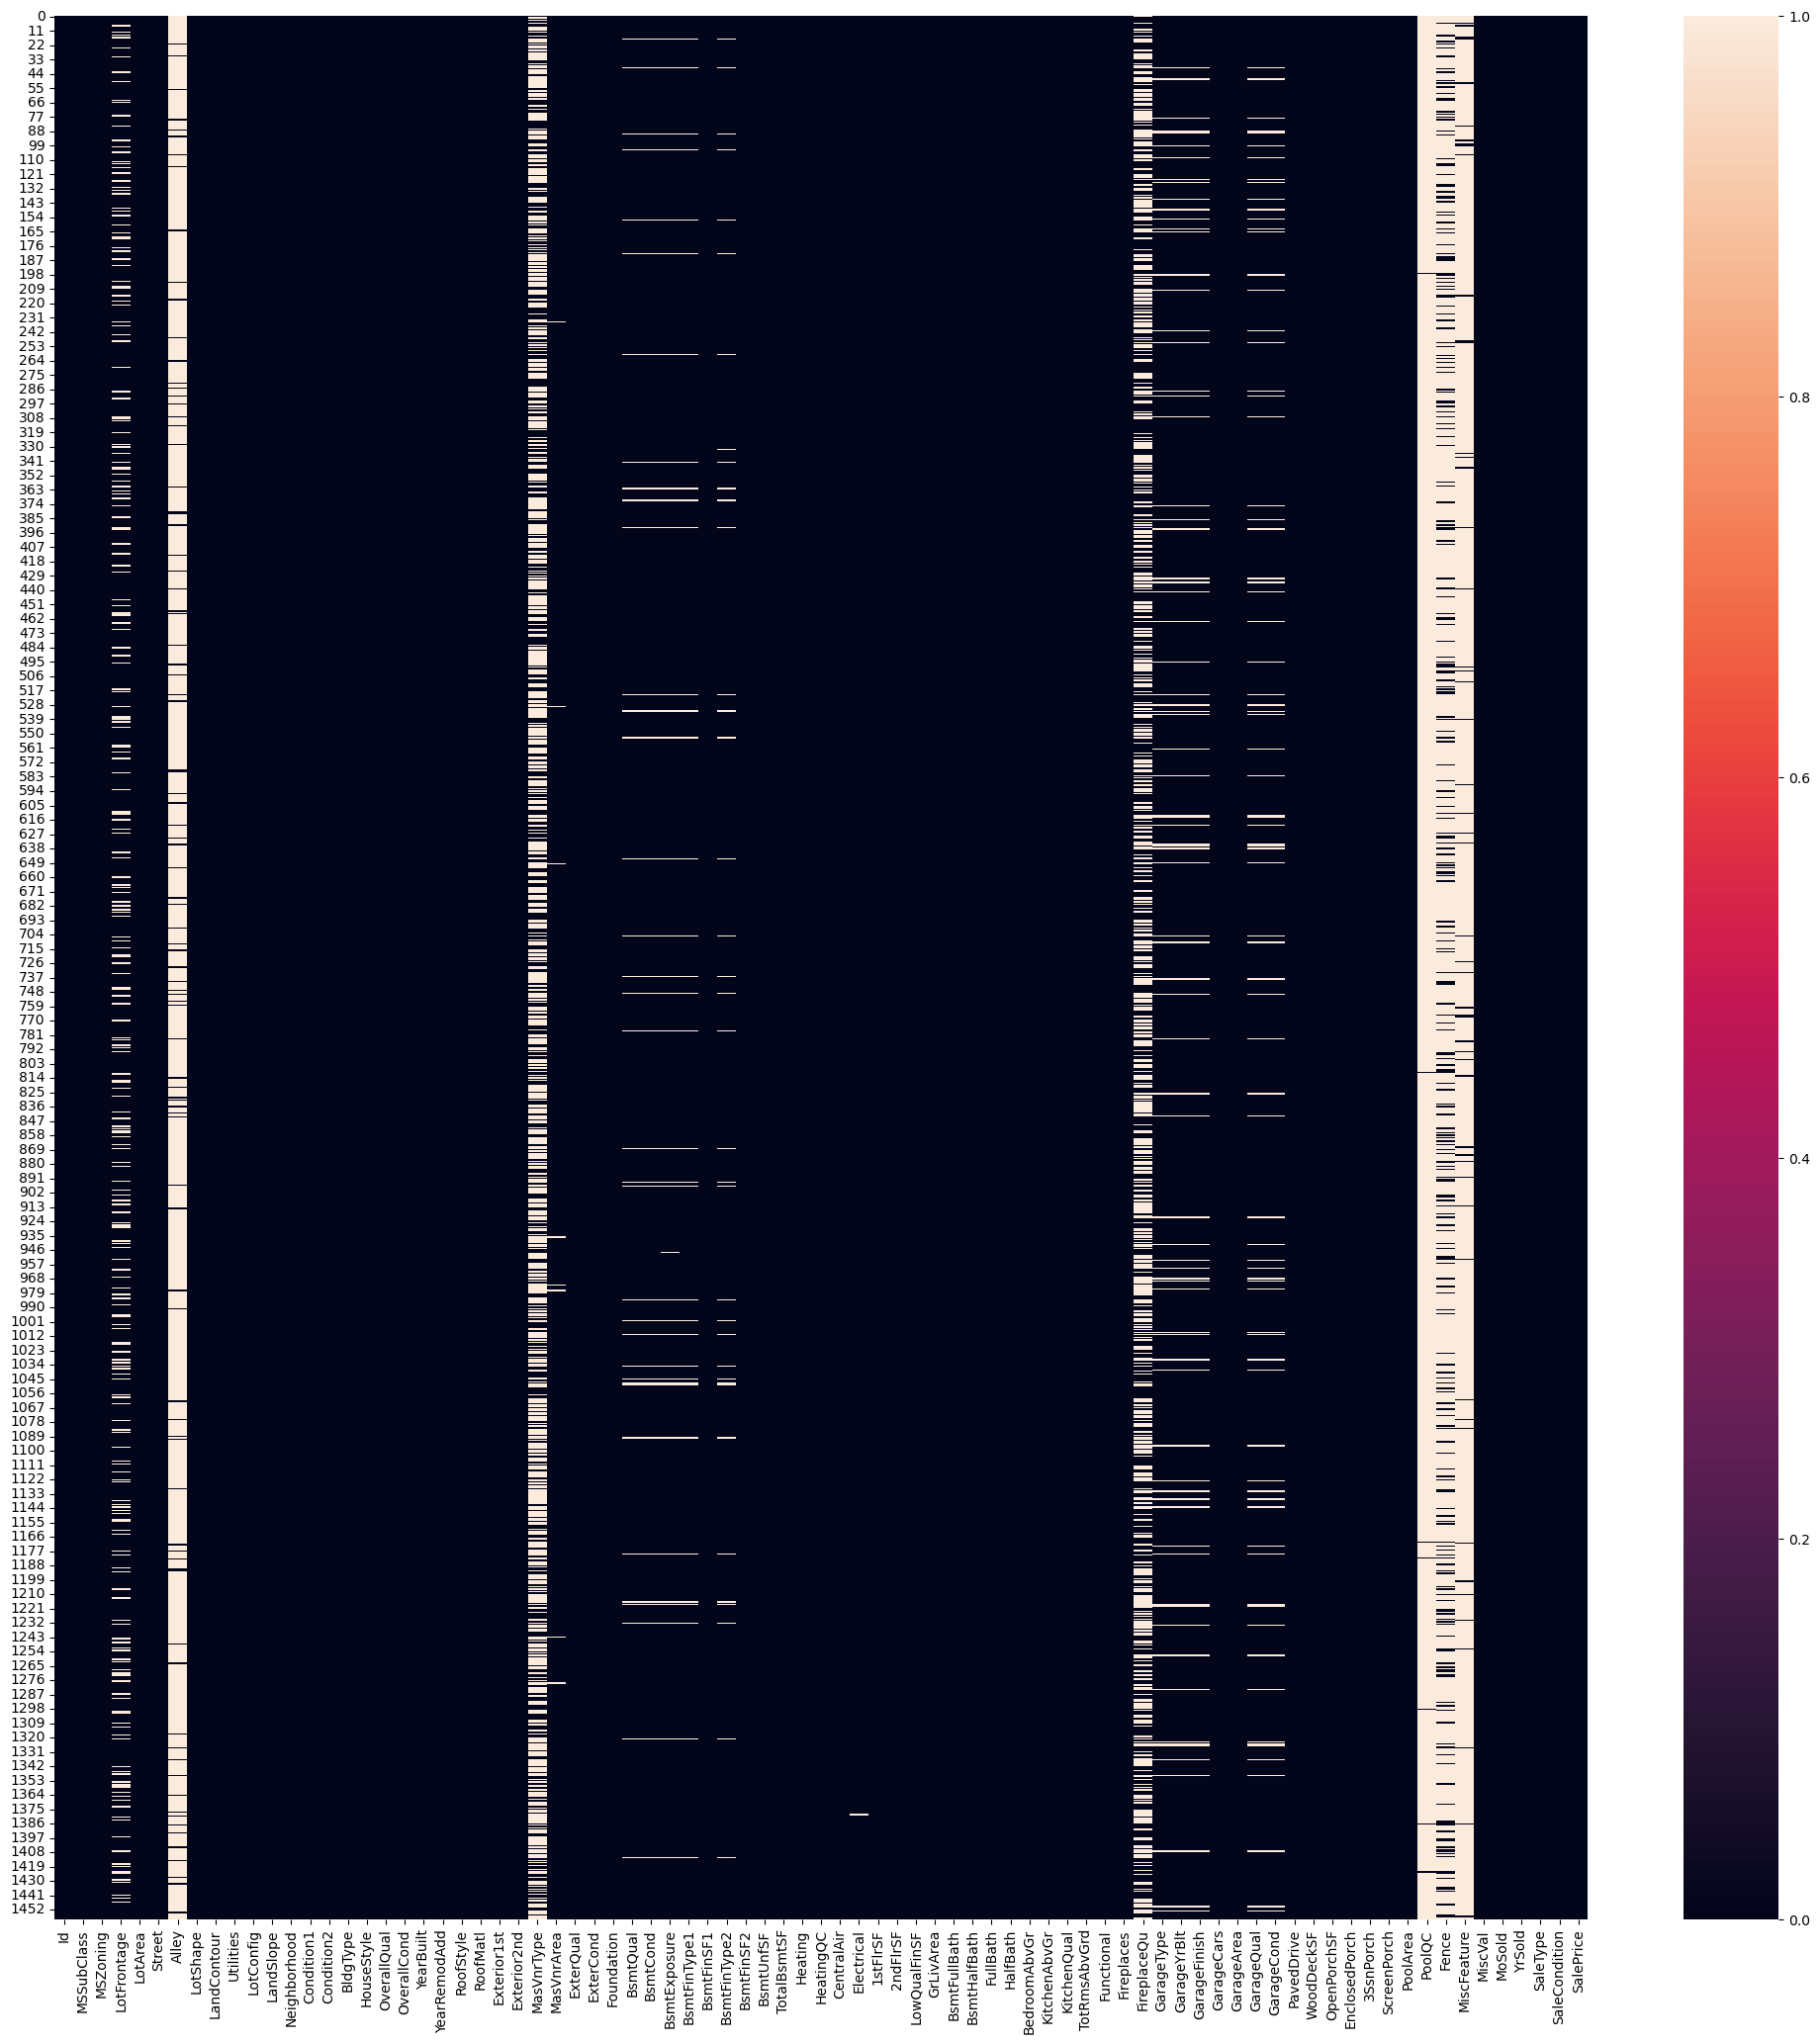

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(25, 25))
sns.heatmap(h_df.isnull())
plt.show()

In [62]:
h_df.isnull().sum()/h_df.shape[0]*100

Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
Street            0.000000
Alley            93.767123
LotShape          0.000000
LandContour       0.000000
Utilities         0.000000
LotConfig         0.000000
LandSlope         0.000000
Neighborhood      0.000000
Condition1        0.000000
Condition2        0.000000
BldgType          0.000000
HouseStyle        0.000000
OverallQual       0.000000
OverallCond       0.000000
YearBuilt         0.000000
YearRemodAdd      0.000000
RoofStyle         0.000000
RoofMatl          0.000000
Exterior1st       0.000000
Exterior2nd       0.000000
MasVnrType       59.726027
MasVnrArea        0.547945
ExterQual         0.000000
ExterCond         0.000000
Foundation        0.000000
BsmtQual          2.534247
BsmtCond          2.534247
BsmtExposure      2.602740
BsmtFinType1      2.534247
BsmtFinSF1        0.000000
BsmtFinType2      2.602740
BsmtFinSF2        0.000000
B

In [64]:
null_var=h_df.isnull().sum()/h_df.shape[0]*100
null_var

Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
Street            0.000000
Alley            93.767123
LotShape          0.000000
LandContour       0.000000
Utilities         0.000000
LotConfig         0.000000
LandSlope         0.000000
Neighborhood      0.000000
Condition1        0.000000
Condition2        0.000000
BldgType          0.000000
HouseStyle        0.000000
OverallQual       0.000000
OverallCond       0.000000
YearBuilt         0.000000
YearRemodAdd      0.000000
RoofStyle         0.000000
RoofMatl          0.000000
Exterior1st       0.000000
Exterior2nd       0.000000
MasVnrType       59.726027
MasVnrArea        0.547945
ExterQual         0.000000
ExterCond         0.000000
Foundation        0.000000
BsmtQual          2.534247
BsmtCond          2.534247
BsmtExposure      2.602740
BsmtFinType1      2.534247
BsmtFinSF1        0.000000
BsmtFinType2      2.602740
BsmtFinSF2        0.000000
B

In [65]:
drop_cols=null_var[null_var > 17].keys()
drop_cols

Index(['LotFrontage', 'Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')

In [69]:
df2_drop_clm=h_df.drop(columns=drop_cols)
df2_drop_clm

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000
5,6,50,RL,14115,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,320,0,0,700,10,2009,WD,Normal,143000
6,7,20,RL,10084,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2007,WD,Normal,307000
7,8,60,RL,10382,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,228,0,0,0,350,11,2009,WD,Normal,200000
8,9,50,RM,6120,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,205,0,0,0,0,4,2008,WD,Abnorml,129900
9,10,190,RL,7420,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,1,2008,WD,Normal,118000


In [70]:
df3_drop_rows=df2_drop_clm.dropna()

In [71]:
df3_drop_rows.shape

(1338, 74)

<Axes: >

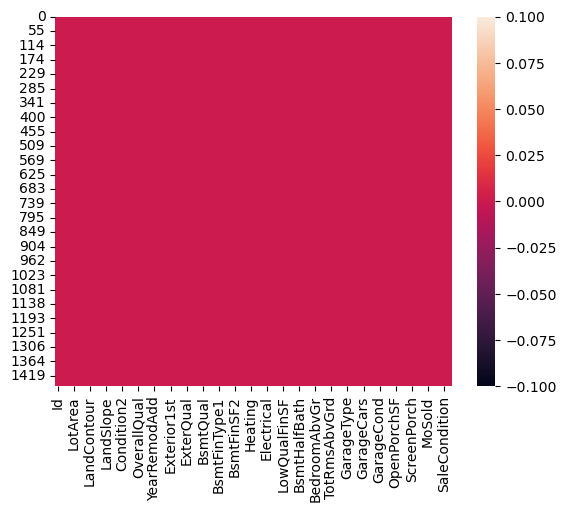

In [72]:
sns.heatmap(df3_drop_rows.isnull())

In [73]:
df3_drop_rows.isna().sum().sum()

np.int64(0)

# Numerical Value Data Distribution

In [74]:
import seaborn as sns 

In [76]:
df3_drop_rows.select_dtypes(include=['int64','float64']).columns

Index(['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

C:\Users\Suha Ali\AppData\Local\Temp\ipykernel_3724\498137754.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(h_df['MSSubClass'])


<Axes: xlabel='MSSubClass', ylabel='Density'>

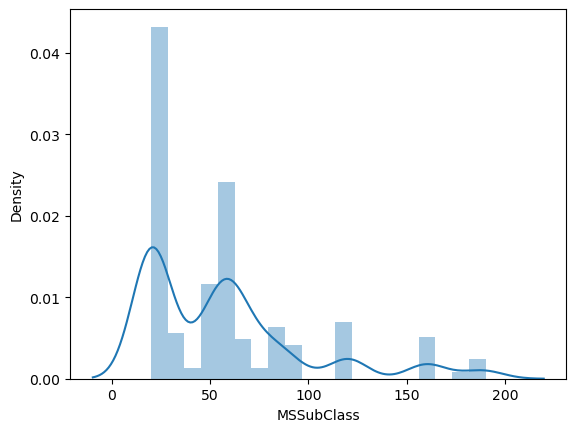

In [81]:
sns.distplot(h_df['MSSubClass'])

C:\Users\Suha Ali\AppData\Local\Temp\ipykernel_3724\735329885.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df3_drop_rows['MSSubClass'])


<Axes: xlabel='MSSubClass', ylabel='Density'>

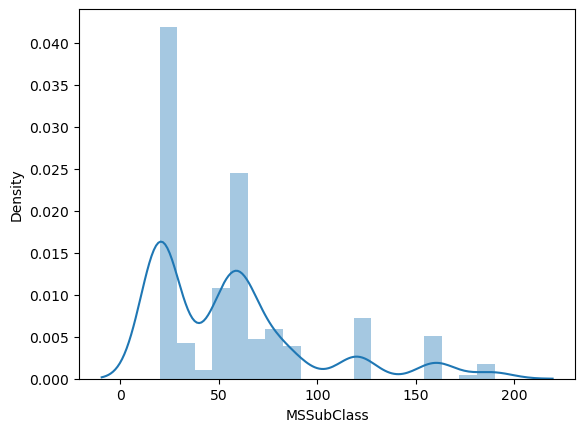

In [83]:
sns.distplot(df3_drop_rows['MSSubClass'])

In [85]:
data=['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice']

C:\Users\Suha Ali\AppData\Local\Temp\ipykernel_3724\875322432.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(h_df[var],bins=20)
C:\Users\Suha Ali\AppData\Local\Temp\ipykernel_3724\875322432.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df3_drop_rows[var],bins=20)
C:\Users\Suha Ali\App

ValueError: num must be an integer with 1 <= num <= 36, not 37

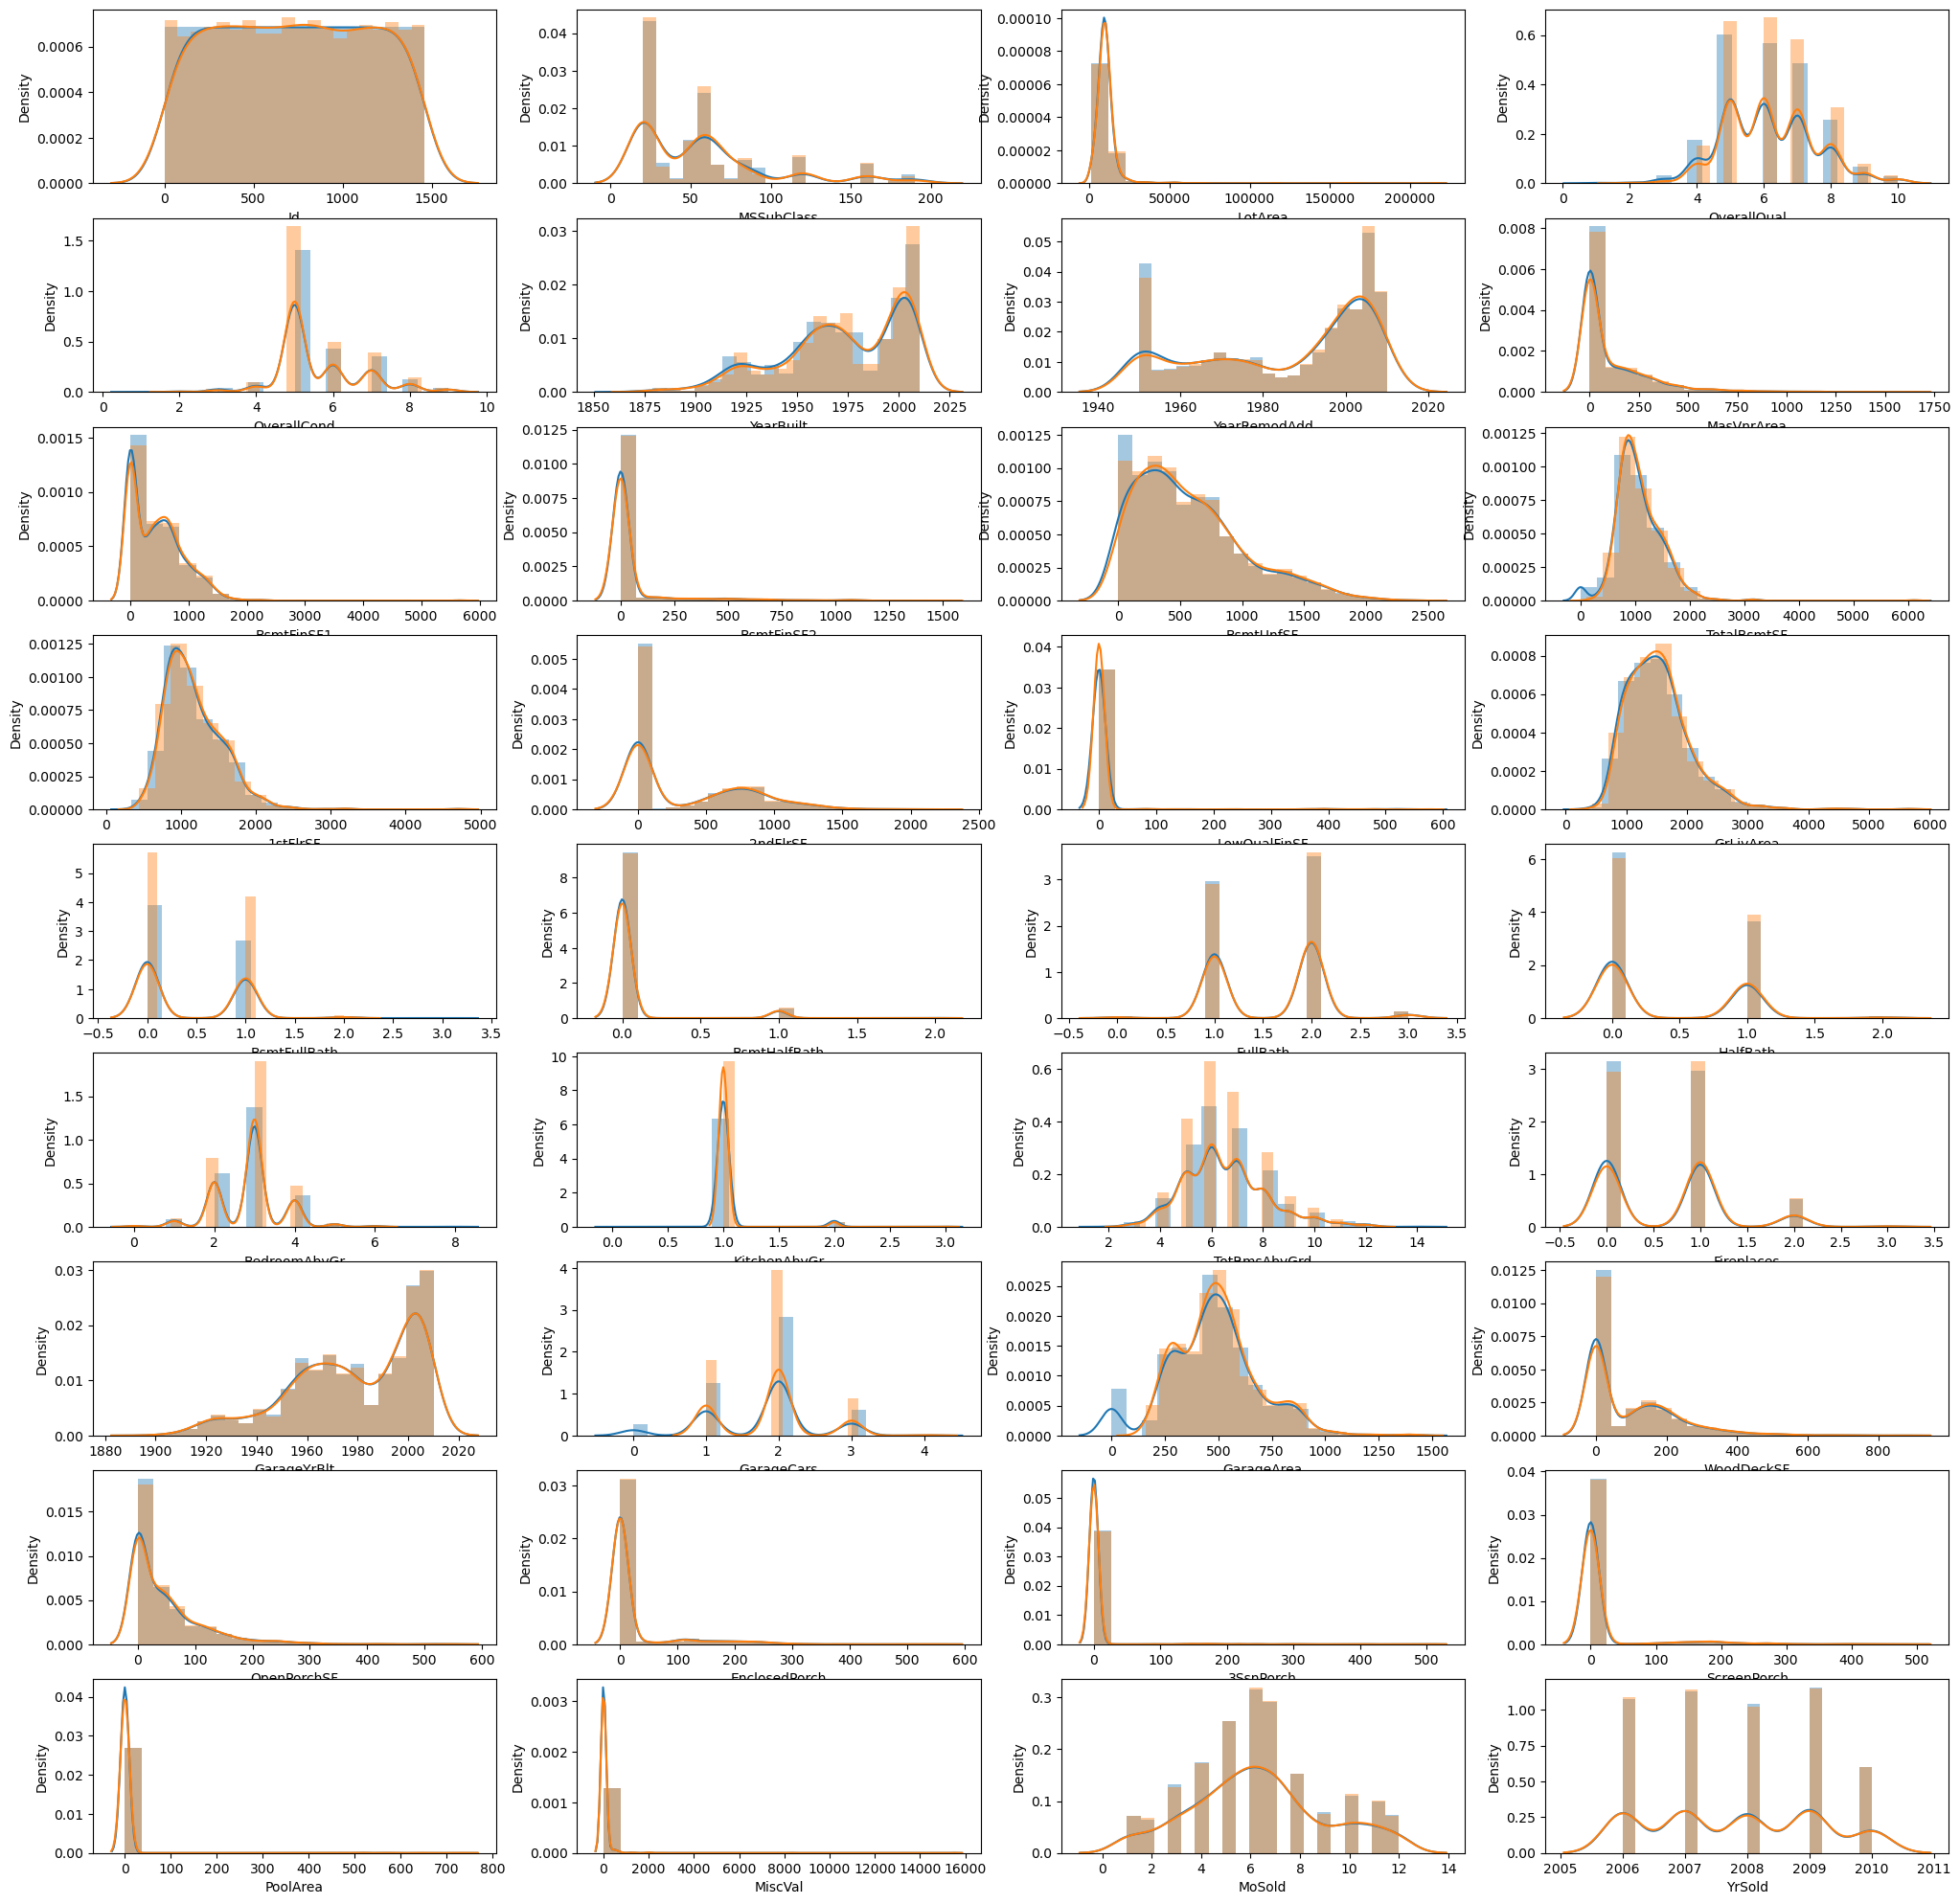

In [88]:
plt.figure(figsize=(25,25))
for i,var in enumerate(data):
    plt.subplot(9,4,i+1)
    sns.distplot(h_df[var],bins=20)
    sns.distplot(df3_drop_rows[var],bins=20)

# Categorial Data Distribution

In [89]:
df3_drop_rows.select_dtypes(include=['object']).columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [90]:
h_df['MSZoning'].value_counts()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

In [92]:
h_df['MSZoning'].value_counts()/df3_drop_rows.shape[0]

MSZoning
RL         0.860239
RM         0.162930
FV         0.048580
RH         0.011958
C (all)    0.007474
Name: count, dtype: float64

In [93]:
h_df['MSZoning'].value_counts()/df3_drop_rows.shape[0]*100

MSZoning
RL         86.023916
RM         16.292975
FV          4.857997
RH          1.195815
C (all)     0.747384
Name: count, dtype: float64

In [94]:
df3_drop_rows['MSZoning'].value_counts()/df3_drop_rows.shape[0]*100

MSZoning
RL         79.671151
RM         14.275037
FV          4.633782
RH          0.822123
C (all)     0.597907
Name: count, dtype: float64

In [96]:
pd.concat([h_df['MSZoning'].value_counts()/h_df.shape[0]*100,
           df3_drop_rows['MSZoning'].value_counts()/df3_drop_rows.shape[0] * 100],
           axis=1,
           keys=['MSZoning_Org','MSZoning_clean'])

,MSZoning_Org,MSZoning_clean
MSZoning,,
RL,78.835616,79.671151
RM,14.931507,14.275037
FV,4.452055,4.633782
RH,1.095890,0.822123
C (all),0.684932,0.597907
